# Session 3 — Pixel Losses and Honest Scores 🧪

**Time:** 35–40 minutes  
**Goal:** score a segmentation prediction while excluding ignored border pixels.

You will work with tiny masks where every count is visible, then use the same accumulation pattern used for a validation set.

## 0. Setup

    This lab has no download and no training step. Run the cells in order.

In [ ]:
import torch
import torch.nn.functional as F

torch.manual_seed(7)
IGNORE_INDEX = 255
CLASS_NAMES = ['background', 'pet']
print('PyTorch:', torch.__version__)

## 1. From logits to a mask (5 min)

A model gives two **logits** per pixel: one for background and one for pet. Softmax turns each pair into probabilities that sum to one; `argmax` selects the larger probability.

In [ ]:
# Shape: [batch, classes, height, width]
logits = torch.tensor([[[[3.0, -1.0], [0.2, 1.2]],
                        [[-1.0, 3.0], [1.5, 0.3]]]])
probabilities = logits.softmax(dim=1)
prediction = probabilities.argmax(dim=1)

print('logits shape:       ', tuple(logits.shape))
print('probability sums:\n', probabilities.sum(dim=1))
print('prediction shape:   ', tuple(prediction.shape))
print('predicted labels:\n', prediction[0])
assert torch.allclose(probabilities.sum(dim=1), torch.ones_like(probabilities[:, 0]))
assert prediction.shape == (1, 2, 2)

## 2. Ignored borders do not vote (6 min)

Oxford-IIIT Pet trimaps use `255` for an ambiguous border. It is neither background nor pet, so it must be excluded from both the loss and every metric.

In [ ]:
targets = torch.tensor([[[0, 1], [IGNORE_INDEX, 0]]])
valid = targets != IGNORE_INDEX
loss = F.cross_entropy(logits, targets, ignore_index=IGNORE_INDEX)

print('valid pixels:', int(valid.sum()), 'of', targets.numel())
print('valid mask:\n', valid[0])
print(f'cross-entropy on valid pixels only: {loss.item():.3f}')
assert int(valid.sum()) == 3

## 3. Exercise E1 — accumulate only valid pixels (10 min)

Complete the helper below. It must update a 2×2 confusion matrix whose **rows are true classes** and **columns are predicted classes**. Ignore every target equal to `255`.

In [ ]:
# TODO: update the confusion matrix using only target != IGNORE_INDEX pixels

#!DONE...

def update_confusion(confusion, target, predicted):
    # Keep only valid pixels
    valid = target != IGNORE_INDEX
    target_valid = target[valid]
    predicted_valid = predicted[valid]

    # Rows = true class, columns = predicted class
    for true_class, predicted_class in zip(target_valid, predicted_valid):
        confusion[true_class, predicted_class] += 1

    return confusion


def scores_from_confusion(confusion):
    # Pixel accuracy = correct predictions / total valid pixels
    correct = torch.diag(confusion).sum()
    total = confusion.sum()
    accuracy = (correct.float() / total).item()

    # IoU for each class:
    # IoU = TP / (TP + FP + FN)
    true_positive = torch.diag(confusion).float()
    false_positive = confusion.sum(dim=0).float() - true_positive
    false_negative = confusion.sum(dim=1).float() - true_positive

    denominator = true_positive + false_positive + false_negative

    class_iou = torch.where(
        denominator > 0,
        true_positive / denominator,
        torch.zeros_like(denominator)
    )

    return accuracy, class_iou


In [ ]:
# Two small saved predictions: accumulate counts first, then score once.
batch_targets = [
    torch.tensor([[0, 1], [1, IGNORE_INDEX]]),
    torch.tensor([[0, 0], [1, 1]]),
]
batch_predictions = [
    torch.tensor([[0, 1], [0, 1]]),
    torch.tensor([[0, 1], [1, 0]]),
]

confusion = torch.zeros((2, 2), dtype=torch.int64)
for target, predicted in zip(batch_targets, batch_predictions):
    confusion = update_confusion(confusion, target, predicted)

accuracy, class_iou = scores_from_confusion(confusion)
print('rows=true, columns=predicted')
print(confusion)
print(f'dataset pixel accuracy: {accuracy:.3f}')
print(f'background IoU: {class_iou[0]:.3f}; pet IoU: {class_iou[1]:.3f}')
assert confusion.sum().item() == 7  # one of eight cells was ignored
assert torch.all((class_iou >= 0) & (class_iou <= 1))

**Why accumulate?** Averaging IoU separately for each image gives every image equal weight, even if one has many more valid pixels. A validation report should state its aggregation rule; here we total counts over the dataset before calculating the score.

## 4. Exercise E2 — the worked 4×4 pet IoU (8 min)

For the pet class, find `TP`, `FP`, and `FN`. The ignored lower-right cell must disappear before counting. The expected result is $3/(3+1+1)=0.60$.

In [ ]:
target_4x4 = torch.tensor([
    [1, 1, 0, 0],
    [1, 1, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, IGNORE_INDEX],
])
predicted_4x4 = torch.tensor([
    [1, 1, 0, 0],
    [1, 0, 1, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 1],
])

In [ ]:
# TODO: calculate the pet TP, FP, FN, and IoU while excluding ignored labels

#!DONE...

valid = target_4x4 != IGNORE_INDEX

target_valid = target_4x4[valid]
predicted_valid = predicted_4x4[valid]

TP = ((target_valid == 1) & (predicted_valid == 1)).sum().item()
FP = ((target_valid == 0) & (predicted_valid == 1)).sum().item()
FN = ((target_valid == 1) & (predicted_valid == 0)).sum().item()

pet_iou = TP / (TP + FP + FN)

print(f'TP: {TP}')
print(f'FP: {FP}')
print(f'FN: {FN}')
print(f'pet IoU: {pet_iou:.2f}')

assert TP == 3
assert FP == 1
assert FN == 1
assert pet_iou == 0.60


## 5. Accuracy can hide a bad foreground mask (5 min)

Suppose a 10×10 image contains only four pet pixels. A model predicts every pixel as background. It is correct on 96 of 100 pixels, but it finds none of the pet.

In [ ]:
rare_target = torch.zeros((10, 10), dtype=torch.int64)
rare_target[:2, :2] = 1
all_background = torch.zeros_like(rare_target)

rare_confusion = torch.zeros((2, 2), dtype=torch.int64)
rare_confusion = update_confusion(rare_confusion, rare_target, all_background)
rare_accuracy, rare_iou = scores_from_confusion(rare_confusion)
print(f'pixel accuracy: {rare_accuracy:.2%}')
print(f'pet IoU: {rare_iou[1]:.2f}')
assert rare_accuracy == 0.96 and rare_iou[1] == 0.0

    > TODO: In one or two sentences, explain why the 96% pixel accuracy above is misleading.


    #    El 96% de precisión es engañoso porque la clase de fondo domina la imagen, por lo que predecir todos los píxeles como fondo produce una precisión aparentemente alta. Sin embargo, el modelo no detecta ningún píxel de la mascota, lo cual se refleja en un IoU de 0.0.

## Checkpoint

Before leaving, confirm that you can explain: (1) why `255` is excluded, (2) why the 4×4 pet IoU is 0.60, and (3) why a dataset metric starts from accumulated counts. Next session you will use these metrics to evaluate a pretrained segmentation model.

    El IoU del ejemplo 4×4 es 0.60 porque para pet existen 3 verdaderos positivos, 1 falso positivo y 1 falso negativo:
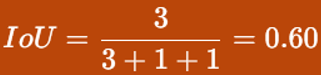